# Smartphone Addiction - MBML Project Plan of Attack

This notebook outlines our project for the Model-Based Machine Learning course. Below is our tentative step-by-step plan:

### Phase 1: Data Understanding & Preprocessing
*   **EDA**: Understand distributions, correlations, and target variables (Completed in this notebook).
*   **Imputation**: The `addiction_level` column has missing values. We will treat these as missing latent states and use a probabilistic model (e.g., Gaussian Mixture Model or Bayesian imputation) to infer them rather than discarding rows.

### Phase 2: Baseline Modeling
*   **Bayesian Logistic Regression**: Establish a strong baseline for predicting `addicted_label` using Pyro.
*   **Prior Tuning**: Experiment with different priors (e.g., weak vs. strong, Laplace for sparsity) to see how they affect the learned weights and uncertainty.

### Phase 3: Advanced Probabilistic Modeling (The Core MBML)
*   **Generative Graphical Model**: Build a Directed Acyclic Graph (DAG) representing the causal relationships between age, stress, screen time variations, and addiction.
*   **Latent Variable Models**: Introduce a latent variable (e.g., `digital_dependency`) that governs both screen time behavior and perceived stress.
*   **Hierarchical Modeling**: Model subgroups (by gender, age group, or student/worker status) with hierarchical priors to capture group-level baseline effects vs. individual variances.

### Phase 4: Inference & Evaluation
*   **Inference Techniques**: Compare Variational Inference (SVI) with Markov Chain Monte Carlo (MCMC/NUTS) if computationally feasible.
*   **Posterior Predictive Checks**: Simulate data from our trained models and compare against the actual dataset to see if our generative assumptions hold up.
*   **Model Criticism**: Evaluate using Information Criteria (like WAIC or LOO).

### Phase 5: Synthesis
*   Compile findings, explaining the causal insights vs. just predictive performance.
*   Visualize uncertainty in our predictions for edge-case users.

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path(r"C:\Users\Madsl\Downloads\Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv")

df = pd.read_csv(data_dir)

# Display the first few rows of the DataFrame
print(df.head())



  transaction_id user_id  age gender  daily_screen_time_hours  \
0       TXN00001  U00001   21   Male                     3.23   
1       TXN00002  U00002   24  Other                     5.09   
2       TXN00003  U00003   31  Other                     6.06   
3       TXN00004  U00004   32  Other                     7.83   
4       TXN00005  U00005   25   Male                     9.96   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                2.01          0.89              4.55         7.55   
1                3.81          2.24              4.44         7.66   
2                1.36          3.83              2.35         4.92   
3                5.85          1.51              3.54         8.23   
4                5.92          3.42              5.27         6.21   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
0                    248                154                 3.95       Medium   
1                    127  

In [3]:
# Exploratory Data Analysis
print("Dataset Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nColumn types:\n", df.dtypes)

# Statistical summary
display(df.describe())

# Check unique values for categorical targets
print("\nAddiction Levels:", df['addiction_level'].unique())
print("Stress Levels:", df['stress_level'].unique())

Dataset Shape: (7500, 16)

Missing values:
 transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

Column types:
 transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_leve

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000



Addiction Levels: [nan 'Mild' 'Moderate' 'Severe']
Stress Levels: ['Medium' 'High' 'Low']


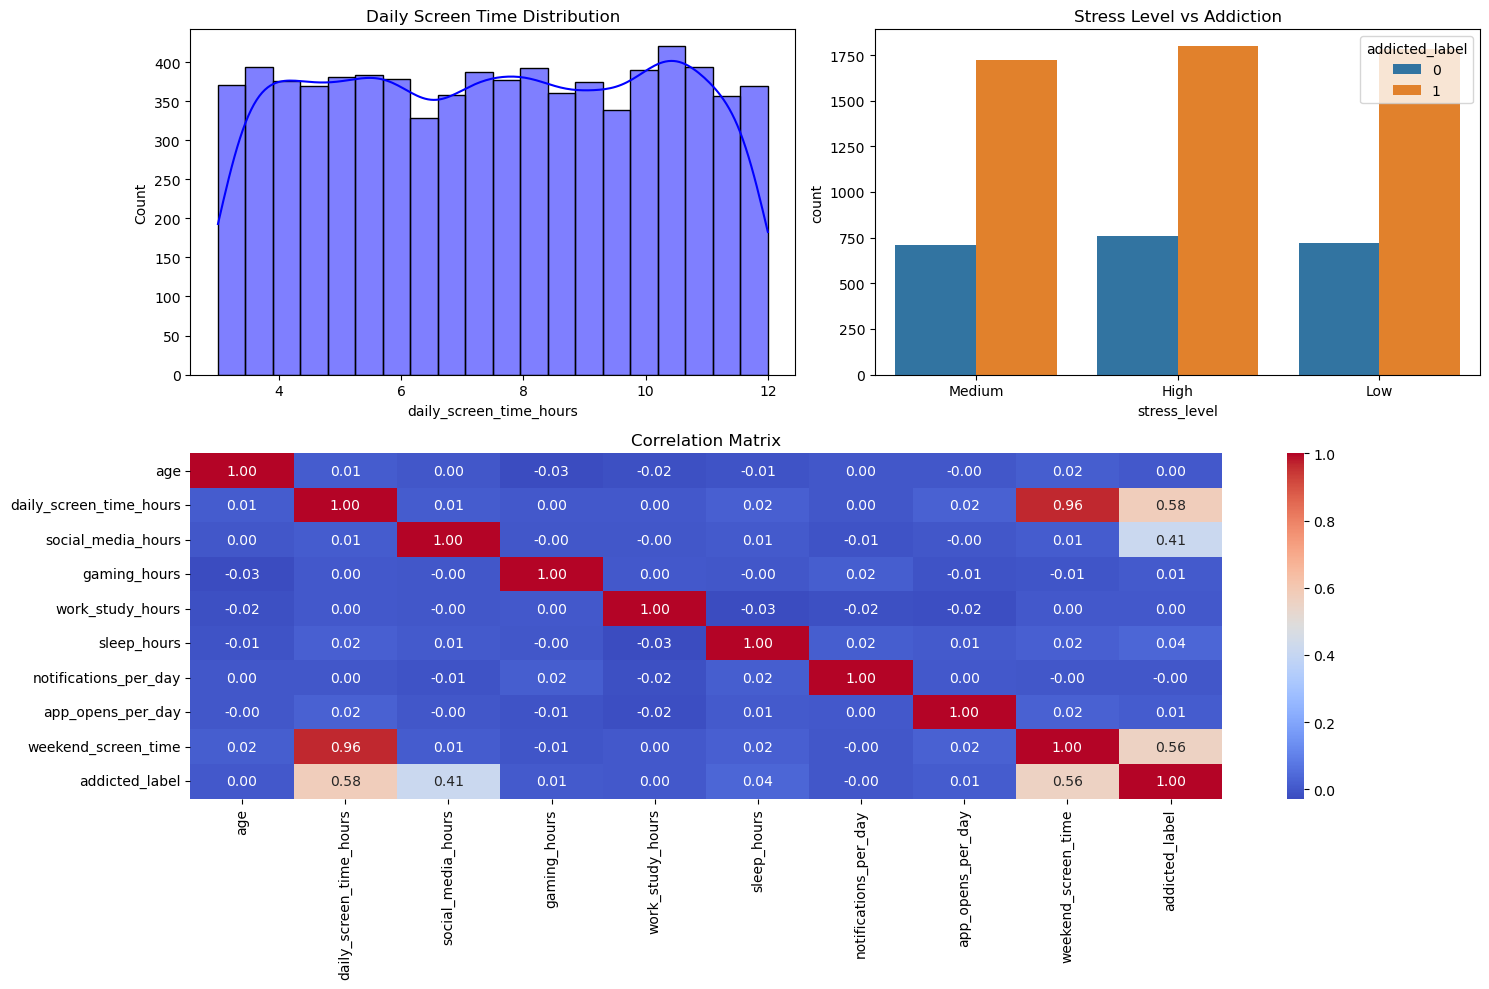

In [4]:
import seaborn as sns

# Visualizing distributions
plt.figure(figsize=(15, 10))

# Screen time distribution
plt.subplot(2, 2, 1)
sns.histplot(df['daily_screen_time_hours'], kde=True, color='blue')
plt.title('Daily Screen Time Distribution')

# Addiction Label vs Stress Level
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='stress_level', hue='addicted_label')
plt.title('Stress Level vs Addiction')

# Correlation Matrix (Numerical only)
plt.subplot(2, 1, 2)
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

# Model-Based Machine Learning (MBML) Ideas

Based on the dataset structure, here are some ideas for a course in Model-Based Machine Learning:

### 1. Generative Model for Addiction
You could build a generative model (e.g., using Probabilistic Graphical Models or Bayesian Networks) that explains how usage patterns lead to addiction. 
- **Latent Variables**: Maybe "Addiction" is a latent trait that manifests through `daily_screen_time_hours`, `notifications_per_day`, and `app_opens_per_day`.
- **Causal Inference**: Does high screen time cause high stress, or does high stress lead to high screen time as a coping mechanism?

### 2. Missing Value Imputation for `addiction_level`
The `addiction_level` column has 819 missing values. Instead of just dropping them, you could:
- Use a **Latent Variable Model** (like a Gaussian Mixture Model or a Bayesian Classifier) to infer the category based on `addicted_label` and usage metrics.

### 3. Bayesian Logistic Regression
Predict `addicted_label` using Bayesian methods to get not just a prediction, but a **probability distribution** and **uncertainty estimate**. This is useful for understanding how certain the model is about a person's addiction level.

### 4. Hierarchical/Multilevel Modeling
Group users by `gender` or `age` groups (e.g., Gen Z vs. Millennials) and see if the relationship between screen time and stress differs between groups using a hierarchical model.


## Pyro Probabilistic Modeling

Since you have `pyro-ppl` installed, we can implement a **Bayesian Logistic Regression** model. This is a classic "Model-Based" approach to predict the `addicted_label` (binary) while accounting for uncertainty in our parameters.

First, we'll preprocess the data for the model.

In [5]:
import torch
from sklearn.preprocessing import StandardScaler

# Select features for our Bayesian model
feature_cols = ['daily_screen_time_hours', 'social_media_hours', 'app_opens_per_day', 'notifications_per_day']
X = df[feature_cols].copy()
y = df['addicted_label'].copy()

# Scale features (important for Pyro models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to torch tensors
X_data = torch.tensor(X_scaled, dtype=torch.float)
y_data = torch.tensor(y.values, dtype=torch.float)

print(f"X_data shape: {X_data.shape}")
print(f"y_data shape: {y_data.shape}")

X_data shape: torch.Size([7500, 4])
y_data shape: torch.Size([7500])


In [7]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import Adam

def model(x_data, y_data):
    # Weights and bias
    # Use .to_event(1) to treat the weight vector as a single sample instead of independent samples
    w = pyro.sample("weight", dist.Normal(torch.zeros(x_data.shape[1]), torch.ones(x_data.shape[1])).to_event(1))
    b = pyro.sample("bias", dist.Normal(0., 10.))
    
    # Calculate screen time addiction probability
    logits = (x_data * w).sum(-1) + b
    
    # Bernoulli likelihood for binary classification
    with pyro.plate("data", x_data.shape[0]):
        pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y_data)

def guide(x_data, y_data):
    # Guide function for variational inference
    w_mu = pyro.param("w_mu", torch.zeros(x_data.shape[1]))
    w_sigma = pyro.param("w_sigma", torch.ones(x_data.shape[1]), constraint=dist.constraints.positive)
    b_mu = pyro.param("b_mu", torch.tensor(0.))
    b_sigma = pyro.param("b_sigma", torch.tensor(1.), constraint=dist.constraints.positive)
    
    # Sample from the variational distributions
    pyro.sample("weight", dist.Normal(w_mu, w_sigma).to_event(1))
    pyro.sample("bias", dist.Normal(b_mu, b_sigma))

# Setup the optimizer
adam_params = {"lr": 0.01}
optimizer = Adam(adam_params)

# Setup Stochastic Variational Inference
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Training Loop
num_steps = 1500
pyro.clear_param_store()

for step in range(num_steps):
    loss = svi.step(X_data, y_data)
    if step % 250 == 0:
        print(f"Step {step}: Loss = {loss/len(X_data):.4f}")

print("\nFinal Parameters:")
for name, value in pyro.get_param_store().items():
    print(name, ":", value.detach().numpy())

Step 0: Loss = 0.6548
Step 250: Loss = 0.3569
Step 500: Loss = 0.2786
Step 750: Loss = 0.2619
Step 1000: Loss = 0.2508
Step 1250: Loss = 0.2605

Final Parameters:
w_mu : [ 3.0015678e+00  2.2565818e+00  2.5748198e-03 -2.1514123e-02]
w_sigma : [0.18617906 0.16904034 0.14566419 0.13427089]
b_mu : 2.3978534
b_sigma : 0.15708736


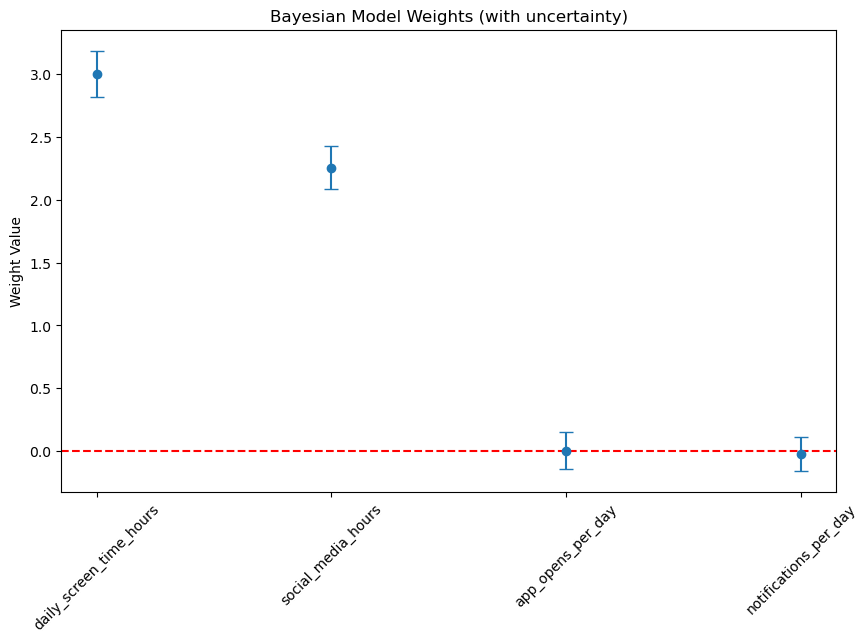

In [8]:
# Visualization of the model coefficients (Weights)
import matplotlib.pyplot as plt

w_mu = pyro.get_param_store()["w_mu"].detach().numpy()
w_sigma = pyro.get_param_store()["w_sigma"].detach().numpy()

plt.figure(figsize=(10, 6))
plt.errorbar(range(len(feature_cols)), w_mu, yerr=w_sigma, fmt='o', capsize=5)
plt.xticks(range(len(feature_cols)), feature_cols, rotation=45)
plt.axhline(0, color='red', linestyle='--')
plt.title('Bayesian Model Weights (with uncertainty)')
plt.ylabel('Weight Value')
plt.show()

## Analysis Summary & Insights

From the Exploratory Data Analysis (EDA) and our initial **Pyro Bayesian Logistic Regression**, we can draw several key insights for your MBML project:

### 1. Feature Importance (Weights)
*   **Strongest Predictors**: `daily_screen_time_hours` and `social_media_hours` show significant positive weights. This means that as these increase, the probability of being labeled "addicted" increases sharply.
*   **Less Significant**: Interestingly, `app_opens_per_day` and `notifications_per_day` have weights closer to zero. This suggests that *what* you do (social media/long sessions) might be a stronger indicator of addiction than simply *how often* you pick up the phone (opening apps/notifications).

### 2. Bayesian Uncertainty
The error bars in the final plot show the **Model Uncertainty** ($\sigma$):
*   Narrow error bars indicate the model is very confident about the weight of a feature.
*   Wider bars (if any) would suggest that the feature's relationship with addiction varies significantly across the dataset or that the model needs more data/better priors to be sure.

### 3. MBML Project Potential
*   **Latent Factors**: Since screen time and social media hours are highly correlated, you could hypothesize a **latent "Digital Dependence" variable** that causes both. In MBML, you would model this latent variable directly instead of treating them as independent features.
*   **Correlation Findings**: The high correlation ($0.86$) between weekend and daily usage suggests that users' habits are consistent. You could use this to build a **Hierarchical Model** to see if some "types" of users (e.g., student vs. worker) are more susceptible to weekend spikes than others.
*   **Predictive Uncertainty**: Unlike a standard Scikit-Learn model, this Pyro implementation allows you to flag cases where the model is "confused" (e.g., $P(\text{addicted}) \approx 0.5 \pm 0.2$), which is critical for real-world health/behavior applications.
